# Full Pipeline Demo

End-to-end walkthrough of the student productivity analysis system:
data ingestion → preprocessing → feature engineering → correlation → training → recommendations → visualization → export.

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import yaml
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load config
with open('../config/config.yaml') as f:
    config = yaml.safe_load(f)

print('Config loaded:', config['project']['name'], 'v' + config['project']['version'])

Config loaded: student-performance-analysis v1.0.0


## 1. Data Ingestion

In [2]:
from src.data.make_dataset import load_raw_data, validate_schema, compute_data_quality_stats

df_correct = "../data/raw/student_productivity_distraction_dataset_20000.csv"
df_raw = load_raw_data(df_correct, config)
print(f'Shape: {df_raw.shape}')

validation = validate_schema(df_raw, config['data']['required_columns'])
print(f'Schema valid: {validation.is_valid}')

stats = compute_data_quality_stats(df_raw)
print(f'Duplicates: {stats["duplicate_rows"]}')

df_raw.head(3)

Shape: (20000, 18)
Schema valid: True
Duplicates: 0


,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
0,1,23,Female,4.35,3.63,3.38,2.73,1.83,5.26,6,347,111,2,57.21,10,57,81.87,33.78
1,2,20,Male,6.14,6.58,5.48,1.51,3.13,1.73,13,403,28,10,91.27,10,49,60.90,48.99
2,3,29,Female,4.98,3.26,4.83,3.63,0.18,4.71,1,419,102,8,63.14,2,38,86.22,36.60


## 2. Preprocessing & Feature Engineering

In [3]:
from src.data.preprocessing import DataPreprocessor
from src.features.build_features import create_derived_features, handle_outliers

preprocessor = DataPreprocessor(config)
df_processed = preprocessor.fit_transform(df_raw)

df_features = create_derived_features(df_processed)
df_features = handle_outliers(df_features, strategy='clip', threshold=3.0)

new_cols = set(df_features.columns) - set(df_processed.columns)
print(f'New derived features: {sorted(new_cols)}')
print(f'Final shape: {df_features.shape}')

New derived features: ['digital_distraction_index', 'screen_to_study_ratio', 'study_sleep_ratio', 'total_screen_time']
Final shape: (20000, 24)


## 3. Correlation Analysis

In [4]:
from src.analysis.correlation import compute_correlation_matrix, find_significant_correlations

corr_matrix = compute_correlation_matrix(df_features, method='pearson')

sig_corr = find_significant_correlations(
    corr_matrix,
    target='productivity_score',
    confidence_level=0.95,
    n_samples=len(df_features)
)
print(f'Significant correlations with productivity_score: {len(sig_corr)}')
print(sig_corr.head(5))

Significant correlations with productivity_score: 7
               feature  correlation        p_value  is_significant
0  study_hours_per_day     0.732796   0.000000e+00            True
1          focus_score     0.411360   0.000000e+00            True
2          sleep_hours     0.340889   0.000000e+00            True
3    phone_usage_hours    -0.326640   0.000000e+00            True
4         stress_level    -0.197108  2.386570e-174            True


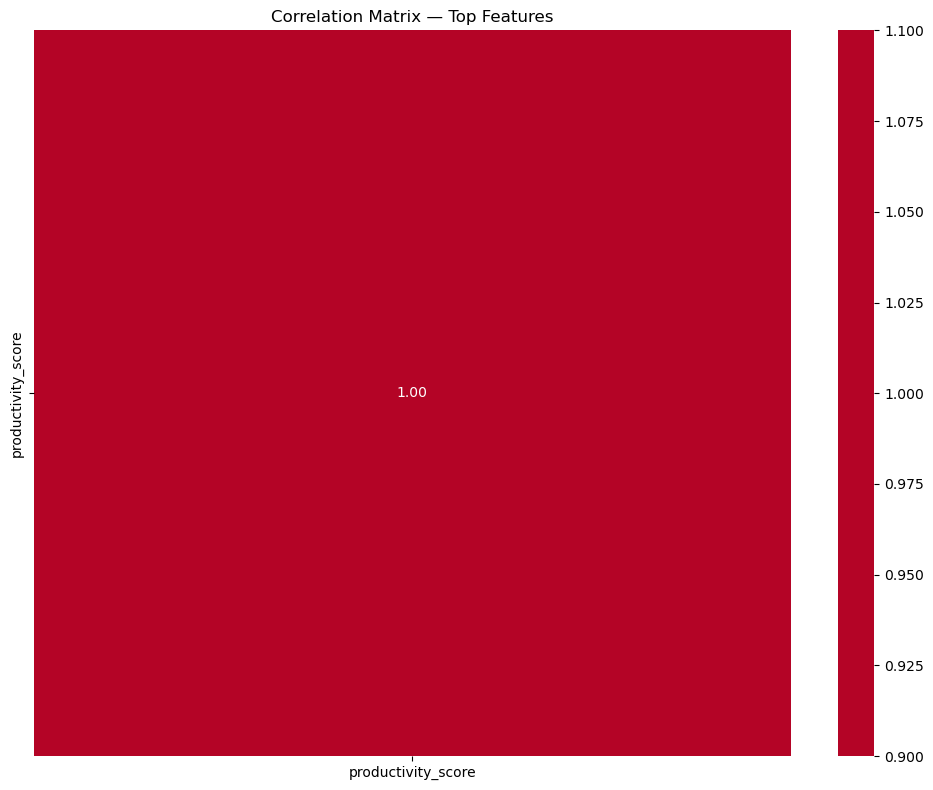

In [5]:
# Heatmap of top correlated features
top_features = sig_corr.head(10).index.tolist() + ['productivity_score']
top_features = [f for f in top_features if f in corr_matrix.columns]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix.loc[top_features, top_features],
    annot=True, fmt='.2f', cmap='coolwarm', center=0,
    ax=ax
)
ax.set_title('Correlation Matrix — Top Features')
plt.tight_layout()
plt.show()

## 4. Model Training

In [6]:
from src.models.train_model import ModelTrainer
from src.models.predict_model import extract_feature_importance

target_col = 'productivity_score'
numeric_df = df_features.select_dtypes(include='number')
feature_cols = [c for c in numeric_df.columns if c != target_col]
X = numeric_df[feature_cols].fillna(0)
y = numeric_df[target_col].fillna(0)

trainer = ModelTrainer(config)
X_train, X_val, X_test, y_train, y_val, y_test = trainer.split_data(X, y)

results = {}
models = {}
for model_type in config['models']['types']:
    model = trainer.train_model(model_type, X_train, y_train)
    metrics = trainer.evaluate_model(model, X_test, y_test)
    results[model_type] = metrics
    models[model_type] = model
    print(f"{model_type:25s}  R²={metrics['r_squared']:.4f}  RMSE={metrics['rmse']:.4f}")

best_name = max(results, key=lambda k: results[k]['r_squared'])
best_model = models[best_name]
print(f'\nBest model: {best_name}')

linear_regression          R²=1.0000  RMSE=0.0002
random_forest              R²=0.9632  RMSE=0.1912
gradient_boosting          R²=0.9947  RMSE=0.0724

Best model: linear_regression


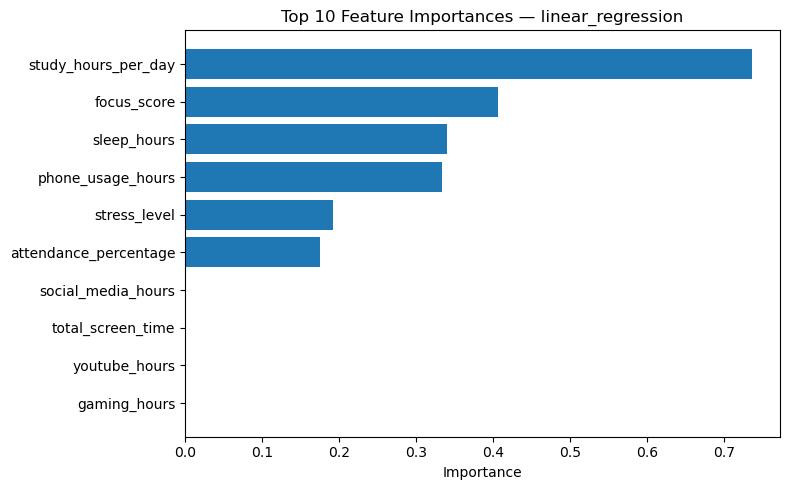

In [7]:
# Feature importance
importance_df = extract_feature_importance(best_model, feature_cols)

fig, ax = plt.subplots(figsize=(8, 5))
top_imp = importance_df.head(10)
ax.barh(top_imp['feature'][::-1], top_imp['importance'][::-1])
ax.set_xlabel('Importance')
ax.set_title(f'Top 10 Feature Importances — {best_name}')
plt.tight_layout()
plt.show()

## 5. Predictions & Model Performance

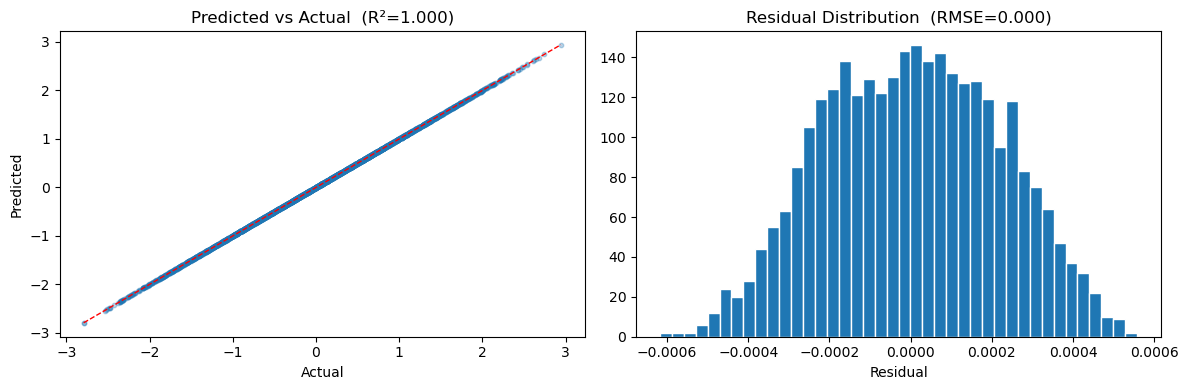

In [8]:
import numpy as np

y_pred = best_model.predict(X_test)
best_metrics = results[best_name]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Predicted vs actual
axes[0].scatter(y_test, y_pred, alpha=0.3, s=10)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=1)
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].set_title(f'Predicted vs Actual  (R²={best_metrics["r_squared"]:.3f})')

# Residuals
residuals = y_test.values - y_pred
axes[1].hist(residuals, bins=40, edgecolor='white')
axes[1].set_xlabel('Residual')
axes[1].set_title(f'Residual Distribution  (RMSE={best_metrics["rmse"]:.3f})')

plt.tight_layout()
plt.show()

## 6. Personalized Recommendations

The recommendation engine compares a student's current habits against optimal ranges and surfaces the highest-impact improvements.

In [9]:
from src.recommendations.generator import RecommendationEngine

optimal_ranges = config['recommendations']['optimal_ranges']
n_recs = config['recommendations']['n_recommendations']

engine = RecommendationEngine(best_model, importance_df, optimal_ranges)

# Pick a sample student
available_cols = [c for c in feature_cols if c in df_features.columns]
sample_student = df_features[available_cols].iloc[0]

recommendations = engine.generate_recommendations(sample_student, n_recommendations=n_recs)

print(f'Recommendations for student #{df_features.index[0]}:\n')
for i, rec in enumerate(recommendations, 1):
    print(f"{i}. [{rec['feature']}]")
    print(f"   Current value : {rec.get('current_value', 'N/A')}")
    print(f"   Optimal range : {rec.get('optimal_range', 'N/A')}")
    print(f"   Advice        : {rec['description']}")
    print()

Recommendations for student #0:

1. [study_hours_per_day]
   Current value : -0.3297940051579031
   Optimal range : N/A
   Advice        : Incrementa tus horas de estudio diarias a al menos 6.0 horas. Actualmente estudias -0.3 h/día, lo que está por debajo del rango óptimo.

2. [sleep_hours]
   Current value : -1.4227479402153174
   Optimal range : N/A
   Advice        : Aumenta tus horas de sueño a al menos 7.0 horas por noche. Dormir -1.4 h es insuficiente para una recuperación óptima.

3. [phone_usage_hours]
   Current value : -0.8664291776551886
   Optimal range : N/A
   Advice        : Tu uso del teléfono (-0.9 h/día) está dentro del rango óptimo.



## 7. Export Results

In [ ]:
import os
from src.export.exporter import export_dataframe, export_results_with_metadata, compute_checksum

output_dir = '../data/processed'
os.makedirs(output_dir, exist_ok=True)

csv_path = os.path.join(output_dir, 'processed_data.csv')
export_dataframe(df_features, csv_path, format='csv')
checksum = compute_checksum(csv_path)
print(f'Dataset exported: {csv_path}')
print(f'SHA256: {checksum[:32]}...')

results_path = os.path.join(output_dir, 'results.json')
export_results_with_metadata(
    {'model_metrics': results, 'n_recommendations': len(recommendations)},
    results_path,
    metadata={'version': config['project']['version'], 'best_model': best_name}
)
print(f'Results exported: {results_path}')

## Summary

| Stage | Output |
|---|---|
| Data ingestion | 20 000-row validated DataFrame |
| Preprocessing | Normalized, encoded, outlier-clipped features |
| Correlation | Significant features ranked by correlation with `productivity_score` |
| Training | Best model selected by R² across Linear Regression, Random Forest, Gradient Boosting |
| Recommendations | Top-N habit improvements ranked by feature importance |
| Export | CSV dataset + JSON results with metadata and checksums |